Class-wise IoU: [0.85945826 0.84747292 0.84629377 0.85776654]
Class-wise Dice: [0.92441791 0.91744016 0.91674877 0.92343847]

Mean IoU: 0.8527
Mean Dice: 0.9205
Pixel Accuracy: 0.9205


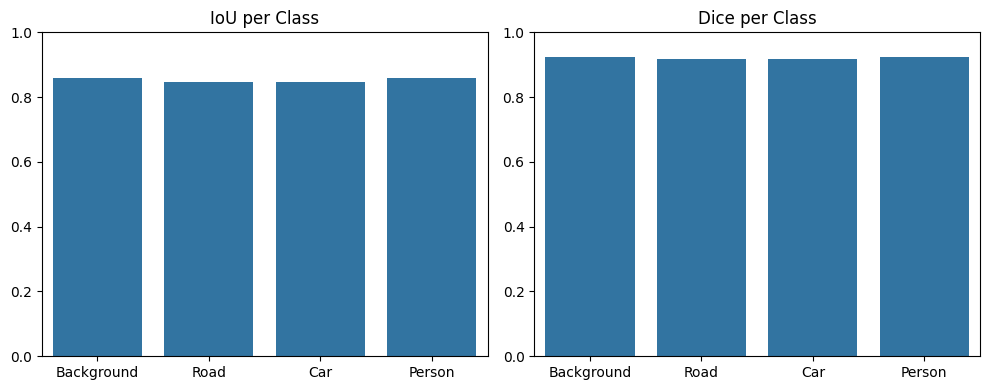

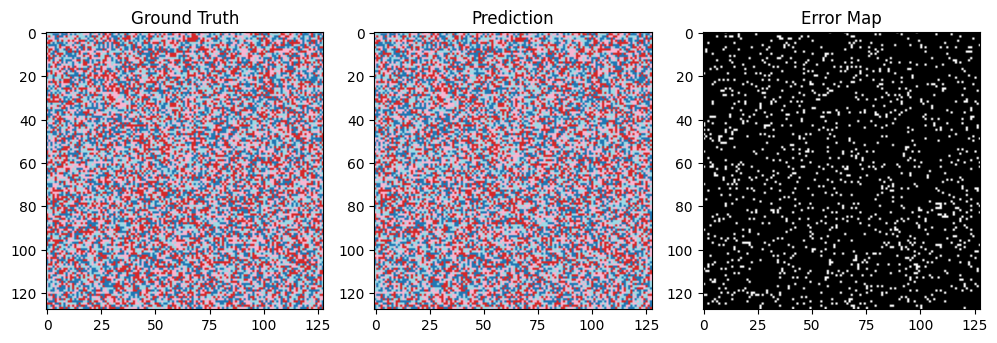

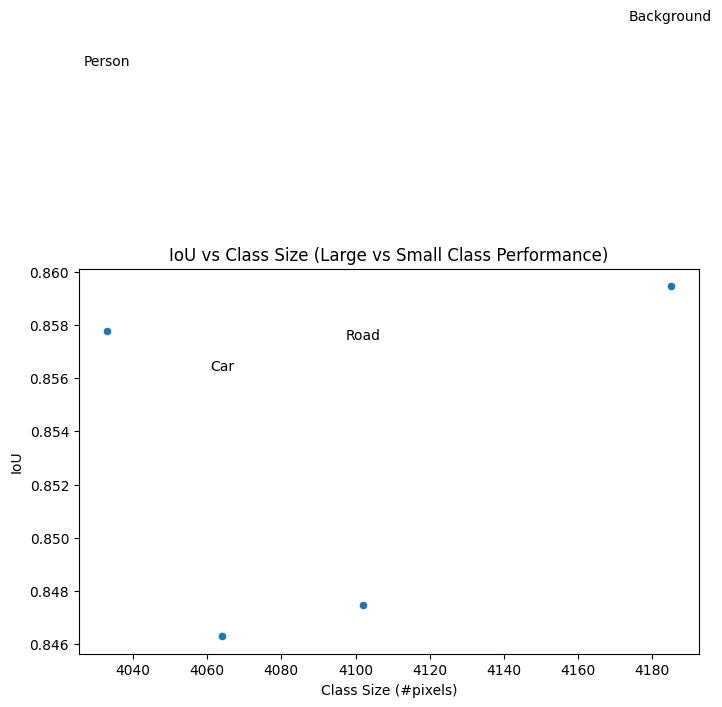


🔍 Observation:
- Large classes (like 'Background' or 'Road') usually have higher IoU/Dice because they dominate the image.
- Small classes (like 'Person') often have lower IoU/Dice due to fewer pixels and higher relative error.


In [1]:
# ================================
# 📦 Setup
# ================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# For reproducibility
np.random.seed(42)

# ================================
# 🧩 Helper: Generate Dummy Data
# ================================
# Suppose we have 4 classes: background, road, car, person
num_classes = 4
height, width = 128, 128

# Simulated ground truth and predictions
y_true = np.random.randint(0, num_classes, (height, width))
y_pred = y_true.copy()

# Add random noise to prediction to simulate errors
noise = np.random.rand(height, width) > 0.9
y_pred[noise] = np.random.randint(0, num_classes, np.sum(noise))

# ================================
# ⚙️ Metric Functions
# ================================
def compute_iou(y_true, y_pred, num_classes):
    iou_per_class = []
    for c in range(num_classes):
        intersection = np.logical_and(y_true == c, y_pred == c).sum()
        union = np.logical_or(y_true == c, y_pred == c).sum()
        iou = intersection / union if union > 0 else np.nan
        iou_per_class.append(iou)
    return np.array(iou_per_class)

def compute_dice(y_true, y_pred, num_classes):
    dice_per_class = []
    for c in range(num_classes):
        intersection = np.logical_and(y_true == c, y_pred == c).sum()
        total = (y_true == c).sum() + (y_pred == c).sum()
        dice = 2 * intersection / total if total > 0 else np.nan
        dice_per_class.append(dice)
    return np.array(dice_per_class)

def compute_pixel_accuracy(y_true, y_pred):
    correct = (y_true == y_pred).sum()
    total = y_true.size
    return correct / total

# ================================
# 📊 Compute Metrics
# ================================
iou = compute_iou(y_true, y_pred, num_classes)
dice = compute_dice(y_true, y_pred, num_classes)
pixel_acc = compute_pixel_accuracy(y_true, y_pred)

mean_iou = np.nanmean(iou)
mean_dice = np.nanmean(dice)

print("Class-wise IoU:", iou)
print("Class-wise Dice:", dice)
print(f"\nMean IoU: {mean_iou:.4f}")
print(f"Mean Dice: {mean_dice:.4f}")
print(f"Pixel Accuracy: {pixel_acc:.4f}")

# ================================
# 📈 Visualization: Metrics
# ================================
classes = ['Background', 'Road', 'Car', 'Person']

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.barplot(x=classes, y=iou)
plt.title("IoU per Class")
plt.ylim(0,1)

plt.subplot(1,2,2)
sns.barplot(x=classes, y=dice)
plt.title("Dice per Class")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# ================================
# 🗺️ Visualization: Error Maps
# ================================
error_map = (y_true != y_pred).astype(np.uint8) * 255

plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(y_true, cmap='tab20')
plt.title("Ground Truth")

plt.subplot(1,3,2)
plt.imshow(y_pred, cmap='tab20')
plt.title("Prediction")

plt.subplot(1,3,3)
plt.imshow(error_map, cmap='gray')
plt.title("Error Map")
plt.tight_layout()
plt.show()

# ================================
# 🔍 Analysis: Large vs Small Classes
# ================================
class_sizes = [np.sum(y_true == c) for c in range(num_classes)]

plt.figure(figsize=(8,5))
sns.scatterplot(x=class_sizes, y=iou)
for i, name in enumerate(classes):
    plt.text(class_sizes[i], iou[i]+0.01, name, ha='center')
plt.xlabel("Class Size (#pixels)")
plt.ylabel("IoU")
plt.title("IoU vs Class Size (Large vs Small Class Performance)")
plt.show()

print("\n🔍 Observation:")
print("- Large classes (like 'Background' or 'Road') usually have higher IoU/Dice because they dominate the image.")
print("- Small classes (like 'Person') often have lower IoU/Dice due to fewer pixels and higher relative error.")
